<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QG001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

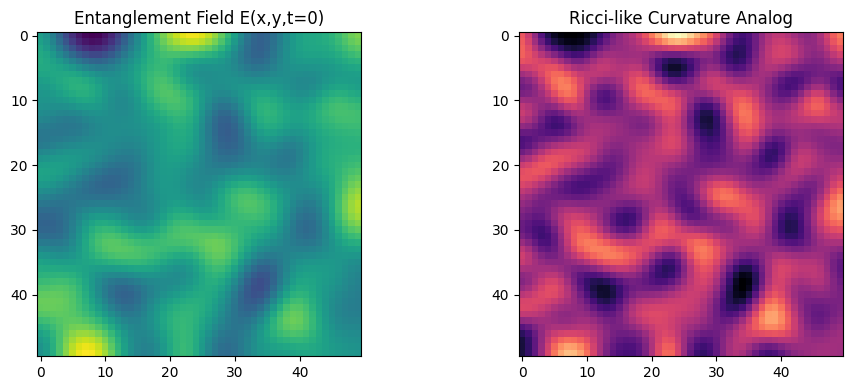

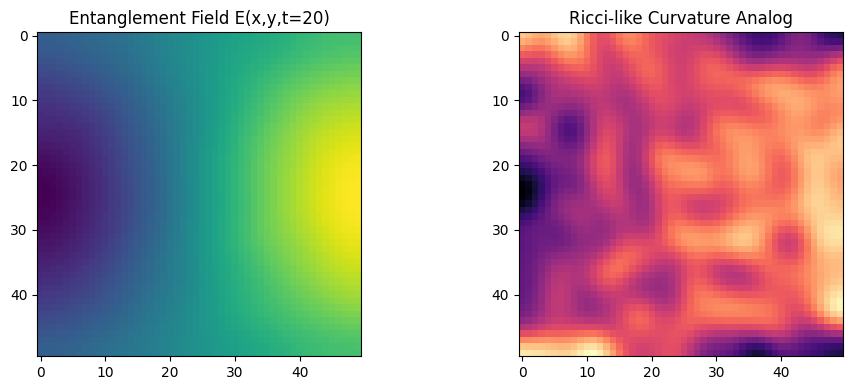

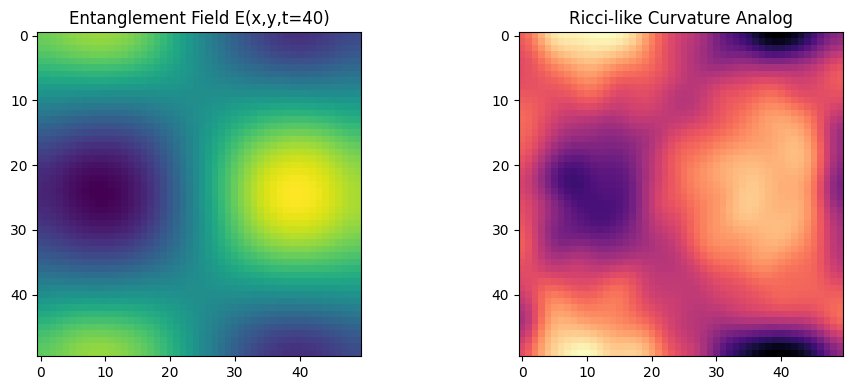

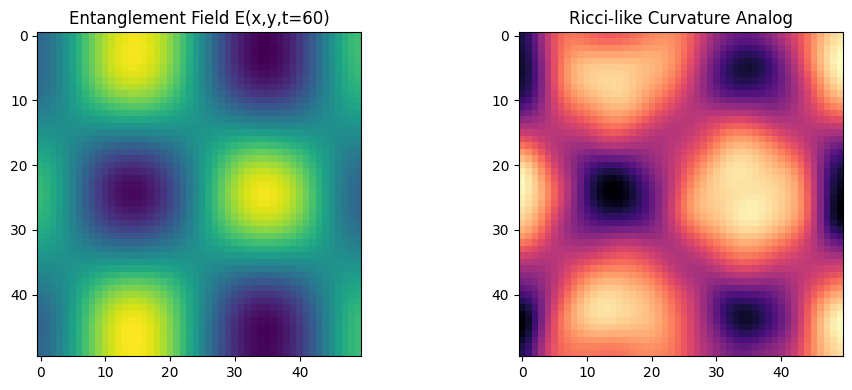

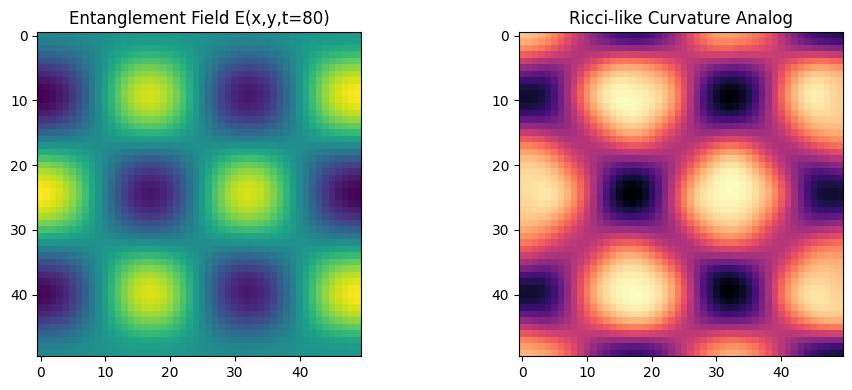

In [1]:
# QG001: Entanglement Gradient → Ricci Tensor
# Author: Chris & Copilot
# Arc IV: Quantum Gravity & Emergent Geometry

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, laplace

# Parameters
grid_size = 50
timesteps = 100
sigma = 3.0  # smoothing for entanglement field

# Initialize entanglement field E(x, y, t)
def initialize_field(grid_size, t):
    x, y = np.meshgrid(np.linspace(-1, 1, grid_size), np.linspace(-1, 1, grid_size))
    pulse = np.sin(2 * np.pi * x * t / timesteps) * np.cos(2 * np.pi * y * t / timesteps)
    noise = np.random.normal(0, 0.1, (grid_size, grid_size))
    return gaussian_filter(pulse + noise, sigma=sigma)

# Compute gradient and Laplacian
def compute_derivatives(E):
    grad_x, grad_y = np.gradient(E)
    lap = laplace(E)
    return grad_x, grad_y, lap

# Ricci-like curvature analog (toy model)
def curvature_analog(grad_x, grad_y, lap):
    return grad_x**2 + grad_y**2 - lap

# Visualization
def plot_fields(E, curvature, t):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].imshow(E, cmap='viridis')
    axs[0].set_title(f'Entanglement Field E(x,y,t={t})')
    axs[1].imshow(curvature, cmap='magma')
    axs[1].set_title('Ricci-like Curvature Analog')
    plt.tight_layout()
    plt.show()

# Run simulation
for t in range(0, timesteps, 20):
    E = initialize_field(grid_size, t)
    grad_x, grad_y, lap = compute_derivatives(E)
    curvature = curvature_analog(grad_x, grad_y, lap)
    plot_fields(E, curvature, t)
